# P8s K-probe — Cross-Input Transfer (`question-only` ↔ `context+question`)

## RQ

**RQ1 — Single-inference feasibility**
> conflicting context까지 읽은 `context+question`(CQ) pre-generation hidden state에서,
> closed-book으로 정의된 K+/K−를 decode할 수 있는가?  → `Train CQ → Test CQ`

충분히 높으면 별도의 closed-book pass 없이
`CQ → prefill hidden → offline K probe → K score → steering → decoding`
이라는 **single LLM inference 구조**의 근거가 된다.
K label 자체는 closed-book correctness로 정의해도 무방하고, 핵심은 **runtime probe input이
CQ 하나뿐**이라는 점이다.

**RQ2 — Representation preservation**
> question-only(Q)에서 학습한 K decision boundary가 context 입력 후에도 작동하는가?
> → `Train Q → Test CQ`

in-domain AUROC가 비슷한 것과 cross-input decision boundary가 같은 것은 **별개**다.
보존 주장은 오직 `Q→CQ` 전이 결과로만 한다.

---
## 실행 순서
이 노트북은 **위에서 아래로 한 번에** 실행하도록 정리돼 있다. 중간에 셀을 끼워넣지 말 것.
무거운 단계(hidden 추출)는 `OUT_DIR`에 캐시되므로 런타임이 끊겨도 재실행하면 이어서 간다.

| 셀 | 내용 | 중단 조건 |
|---|---|---|
| 1–3 | 환경·CONFIG·HF 인증 | 인증 실패 시 중단 |
| 4–6 | 데이터 로드·스키마 고정·정합성 검증 | 4셀 구성이 378/378/234/234 아니면 중단 |
| 7–8 | 프롬프트 빌더·토큰 길이 검증 | truncation 발생 시 확인 후 진행 |
| 9–10 | 모델 로드·hidden 추출 | — |
| 11–13 | fold 고정·4-way transfer·결과표 | — |
| 14 | **sanity check** | `C×Q`가 0.5 아니면 13절 결과 폐기 |
| 15–17 | null·paired score·해석 | — |

In [1]:
import os, re, ast, json, gc, math, warnings
import numpy as np
import pandas as pd
import torch

warnings.filterwarnings("ignore")
print("torch", torch.__version__)
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name} | {p.total_memory/1e9:.1f} GB")
    if p.total_memory < 20e9:
        print("[경고] 8B bfloat16은 약 16GB가 필요하다. T4(16GB)면 빠듯해서 OOM 위험이 있다.\n"
              "       L4 이상 권장. 4bit 양자화를 쓰면 hidden state가 기존 실험과 달라지므로 피할 것.")
else:
    raise RuntimeError("GPU 런타임이 아니다. 런타임 유형을 GPU(L4 권장)로 변경할 것.")

torch 2.11.0+cu128
GPU: NVIDIA A100-SXM4-40GB | 42.4 GB


## 1. CONFIG

#### `p8s_pairs.csv` 파일 업로드 확인

사용자께서 `p8s_pairs.csv` 파일을 업로드해주셨으므로, `CONFIG['P8S_CSV']` 경로가 올바른지 다시 확인하고 다음 단계로 진행하겠습니다.

In [7]:
import os

# CONFIG['P8S_CSV']에 설정된 파일이 실제로 존재하는지 확인합니다.
file_path = CONFIG['P8S_CSV']
if os.path.exists(file_path):
    print(f"파일이 발견되었습니다: {file_path}")
else:
    print(f"오류: 파일을 찾을 수 없습니다: {file_path}")
    print("파일을 `/content/` 경로에 `p8s_pairs.csv` 이름으로 업로드했는지 확인해주세요.")

파일이 발견되었습니다: /content/p8s_pairs.csv


In [2]:
CONFIG = {
    "P8S_CSV": "/content/p8s_pairs.csv",
    "OUT_DIR": "/content/drive/MyDrive/p8s/probe_out",   # Drive 권장 (캐시 보존)

    "MODEL": "meta-llama/Llama-3.1-8B-Instruct",
    "DTYPE": torch.bfloat16,

    "BATCH_SIZE": 4,          # OOM 시 자동으로 절반씩 낮춤
    "MAX_LEN": 1024,
    "HIDDEN_DTYPE": torch.float16,

    "LAYERS_REPORT": [15, 17, 18, 20],
    "LAYER_SWEEP": list(range(1, 33)),
    "LOGREG_C": 0.1,
    "N_SPLITS": 5,

    "N_SHUFFLE": 20,          # 개발용. 최종 보고용이면 200~1000
    "NULL_LAYER": 17,
    "SAVE_SCORE_LAYERS": [15, 17, 18, 20],

    "RUN_BEHAVIOR": False,    # K 실험 우선. behavior는 생성이 필요하므로 기본 off
    "MAX_NEW_TOKENS": 48,
    "SEED": 0,
}

# Drive 미마운트면 로컬로 폴백
if CONFIG["OUT_DIR"].startswith("/content/drive") and not os.path.exists("/content/drive/MyDrive"):
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        CONFIG["OUT_DIR"] = "/content/probe_out"
        print(f"[경고] Drive 마운트 실패({e}). 로컬 사용 → 런타임 종료 시 캐시 소실")

os.makedirs(CONFIG["OUT_DIR"], exist_ok=True)
np.random.seed(CONFIG["SEED"]); torch.manual_seed(CONFIG["SEED"])
print("CSV:", CONFIG["P8S_CSV"], os.path.exists(CONFIG["P8S_CSV"]))
print("OUT:", CONFIG["OUT_DIR"])

Mounted at /content/drive
CSV: /content/p8s_pairs.csv False
OUT: /content/drive/MyDrive/p8s/probe_out


## 2. HuggingFace 인증

Llama-3.1은 gated repo다. 두 가지가 모두 필요하다.
1. https://huggingface.co/meta-llama/Llama-3.1-8B-Instruct 에서 라이선스 동의 → 승인
2. Read 권한 토큰

Colab 왼쪽 **열쇠 아이콘(보안 비밀)** 에 `HF_TOKEN`으로 저장하고 "노트북 액세스"를 켜는 것이
가장 깔끔하다. 없으면 아래 셀이 입력창을 띄운다.

In [3]:
from huggingface_hub import login, model_info

tok_val = None
try:
    from google.colab import userdata
    tok_val = userdata.get("HF_TOKEN")
    print("보안 비밀에서 HF_TOKEN 로드")
except Exception:
    pass

if tok_val:
    os.environ["HF_TOKEN"] = tok_val
    login(token=tok_val)
else:
    print("HF_TOKEN 미설정 → 입력창에 토큰을 붙여넣을 것")
    login()

try:
    info = model_info(CONFIG["MODEL"])
    print("[OK] 모델 접근 가능:", info.id)
except Exception as e:
    raise SystemExit(
        f"[중단] 모델 접근 실패: {type(e).__name__}\n"
        f"  - 토큰이 유효한지\n"
        f"  - {CONFIG['MODEL']} 페이지에서 라이선스 동의가 '승인' 상태인지 확인할 것\n"
        f"  (동의 직후에는 승인까지 시간이 걸릴 수 있다)\n{str(e)[:300]}")

HF_TOKEN 미설정 → 입력창에 토큰을 붙여넣을 것


[OK] 모델 접근 가능: meta-llama/Llama-3.1-8B-Instruct


## 3. 데이터 로드 + 스키마 고정

p8s 실제 스키마 확인 완료. 자동탐지 대신 직접 고정한다.

| 역할 | 컬럼 | 비고 |
|---|---|---|
| question | `question` | qid 컬럼이 없어 이 문자열을 그룹 키로 사용 |
| context | `ctx_text` | |
| K label | `kside` | K+ / K− |
| C label | `ctx_label` | C+ / C− |
| gold | `gold` | **JSON alias 리스트 문자열** → 파싱 필요 |
| contextual answer | `answer_surface` | C+면 `orig_gold`, C−면 `wrong_answer`와 일치 확인됨 |
| parametric answer | `A_cb` | closed-book 답. behavior를 P7 정의대로 만들 수 있음 |
| model output | **없음** | behavior를 하려면 생성 필요 |

In [8]:
COLMAP = {
    "question":     "question",
    "context":      "ctx_text",
    "k_label":      "kside",
    "c_label":      "ctx_label",
    "gold":         "gold",
    "ctx_answer":   "answer_surface",
    "param_answer": "A_cb",
}

df = pd.read_csv(CONFIG["P8S_CSV"])
print("shape:", df.shape)
assert set(COLMAP.values()) <= set(df.columns), \
    f"누락 컬럼: {set(COLMAP.values()) - set(df.columns)}"

def to_binary(s):
    m = s.astype(str).str.strip().str.lower()
    pos = m.str.contains(r"\+|pos|true|yes|^1$", regex=True)
    neg = m.str.contains(r"-|\u2212|neg|false|^no$|^0$", regex=True)
    assert (pos | neg).all(), f"해석 불가 라벨: {sorted(set(m[~(pos | neg)]))}"
    return pos.astype(int)

def parse_aliases(x):
    try:
        v = ast.literal_eval(x) if isinstance(x, str) else x
        return [str(a) for a in v] if isinstance(v, (list, tuple)) else [str(v)]
    except Exception:
        return [str(x)]

df["_K"] = to_binary(df[COLMAP["k_label"]])
df["_C"] = to_binary(df[COLMAP["c_label"]])
df["_qid"] = df[COLMAP["question"]].astype(str)
df["_gold_aliases"] = df[COLMAP["gold"]].apply(parse_aliases)
print("gold alias 예시:", df["_gold_aliases"].iloc[0])

shape: (1224, 16)
gold alias 예시: ['Bollywood', 'HFI', 'HLFI', 'Hindi language film industry', 'Hindi Cinema', 'HIFI']


## 4. 데이터 정합성 검증

여기서 하나라도 깨지면 이후 결과를 쓰지 않는다.

In [9]:
print("=== 4셀 구성 (기대 378/378/234/234) ===")
ct = pd.crosstab(df["_K"].map({1: "K+", 0: "K-"}), df["_C"].map({1: "C+", 0: "C-"}))
print(ct)

print("\nunique questions:", df["_qid"].nunique())
print("질문당 행 수 분포:"); print(df["_qid"].value_counts().value_counts().to_string())

k_per_q = df.groupby("_qid")["_K"].nunique()
n_bad_k = int((k_per_q > 1).sum())
print("\n질문 내 K 불일치:", n_bad_k)
assert n_bad_k == 0, "같은 질문에 K+/K−가 섞여 있다 — closed-book 라벨 정의 확인 필요"

lo = lambda s: s.astype(str).str.strip().str.lower()
chk = df.assign(surf_eq_origgold=lo(df.orig_gold) == lo(df.answer_surface),
                surf_eq_wrong=lo(df.wrong_answer) == lo(df.answer_surface))
print("\n=== answer_surface 정체 (C별 일치율) ===")
print(chk.groupby(df["_C"].map({1: "C+", 0: "C-"}))[
    ["surf_eq_origgold", "surf_eq_wrong"]].mean().round(3))

in_gold = df.apply(
    lambda r: str(r.orig_gold).strip().lower() in
              {a.strip().lower() for a in r._gold_aliases}, axis=1)
df["_ctx_gold_mismatch"] = (df["_C"] == 1) & ~in_gold
print(f"\nC+인데 orig_gold가 gold alias에 없는 행: {int(df._ctx_gold_mismatch.sum())} "
      f"({df._ctx_gold_mismatch.mean()*100:.1f}%)")
print("→ 플래그만 남긴다. 제외하지 않는다(사후 선택 회피). "
      "C+ 결과가 이상하면 df[~df._ctx_gold_mismatch]로 재확인할 것.")

def span_ok(r):
    try:
        return str(r.ctx_text)[int(r.ans_start):int(r.ans_end)].strip().lower() \
               == str(r.answer_surface).strip().lower()
    except Exception:
        return False
sr = df.apply(span_ok, axis=1).mean()
print(f"\nspan 정합률: {sr:.3f}  (K probe는 span을 쓰지 않으므로 이번 실험엔 무해. "
      "attention 실험을 돌릴 때만 문제)")

=== 4셀 구성 (기대 378/378/234/234) ===
_C   C+   C-
_K          
K+  378  378
K-  234  234

unique questions: 612
질문당 행 수 분포:
count
2    612

질문 내 K 불일치: 0

=== answer_surface 정체 (C별 일치율) ===
    surf_eq_origgold  surf_eq_wrong
_C                                 
C+               1.0          0.002
C-               0.0          1.000

C+인데 orig_gold가 gold alias에 없는 행: 11 (0.9%)
→ 플래그만 남긴다. 제외하지 않는다(사후 선택 회피). C+ 결과가 이상하면 df[~df._ctx_gold_mismatch]로 재확인할 것.

span 정합률: 0.886  (K probe는 span을 쓰지 않으므로 이번 실험엔 무해. attention 실험을 돌릴 때만 문제)


## 5. 토크나이저 + 프롬프트 빌더 (token-id 기반)

두 모드가 **질문 문자열·템플릿까지 동일**하고 context 블록 유무만 다르다.
여기가 틀어지면 두 모드 차이가 입력 종류가 아니라 템플릿 차이로 오염된다.

**Truncation 정책**: 문자열이 아니라 token id로 조립하고, 초과 시 **context만** 잘라낸다.
추출 지점이 프롬프트 마지막 토큰이므로 `Answer:` suffix는 어떤 경우에도 보존돼야 한다.

In [10]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tok = AutoTokenizer.from_pretrained(CONFIG["MODEL"])
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

def build_ids(row, mode):
    """returns (ids, n_truncated_ctx_tokens)"""
    q = str(row[COLMAP["question"]]).strip()
    if mode == "q":
        return tok.encode(f"Question: {q}\nAnswer:", add_special_tokens=True)[-CONFIG["MAX_LEN"]:], 0
    assert mode == "cq", mode
    c = str(row[COLMAP["context"]]).strip()
    pre = tok.encode("Context: ", add_special_tokens=True)
    ctx = tok.encode(c, add_special_tokens=False)
    suf = tok.encode(f"\n\nQuestion: {q}\nAnswer:", add_special_tokens=False)
    budget = CONFIG["MAX_LEN"] - len(pre) - len(suf)
    assert budget > 0, f"MAX_LEN이 suffix보다 짧다: {row['_qid']}"
    cut = max(0, len(ctx) - budget)
    return pre + ctx[:budget] + suf, cut

print(tok.decode(build_ids(df.iloc[0], "cq")[0])[:350])
print("\n" + "=" * 60 + "\n")
print(tok.decode(build_ids(df.iloc[0], "q")[0]))

config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


<|begin_of_text|>Context: Farz Aur Kanoon Farz aur Kanoon (English: Duty & Law; Hindi: फ़र्ज़ और कानून) is a 1982 Bollywood Action film, produced by M. Arjuna Raju and A. S. R. Anjineelu under the Roja Movies banner and directed by K. Raghavendra Rao. It stars Jeetendra, Hema Malini, Rati Agnihotri in the pivotal roles and music composed by Laxmika


<|begin_of_text|>Question: What genre is Kanoon?
Answer:


## 6. 토큰 길이 검증 (추출 전 필수)

In [11]:
len_rows, trunc_cq = [], []
for mode in ["cq", "q"]:
    src = df if mode == "cq" else df.drop_duplicates("_qid")
    for _, r in src.iterrows():
        ids, cut = build_ids(r, mode)
        len_rows.append({"mode": mode, "qid": r["_qid"], "n_tok": len(ids), "cut": cut})
        if cut and mode == "cq":
            trunc_cq.append((r["_qid"], cut))

L = pd.DataFrame(len_rows)
stats = L.groupby("mode")["n_tok"].agg(min="min", median="median",
                                       p95=lambda s: float(np.percentile(s, 95)),
                                       max="max", n="count")
stats["ctx_truncated"] = L.groupby("mode")["cut"].apply(lambda s: int((s > 0).sum()))
print(f"MAX_LEN = {CONFIG['MAX_LEN']}")
print(stats.to_string())

if trunc_cq:
    print(f"\n[경고] CQ truncation {len(trunc_cq)}행, 총 {sum(c for _, c in trunc_cq)} 토큰 절단")
    print("  'Question:'/'Answer:' suffix는 보존됨(추출 지점 무결). 다만 p8s C−는 문맥 속 답 단어를")
    print("  치환한 구조라 절단 위치에 따라 치환어가 사라졌을 수 있다. 해당 qid:")
    print("  ", [q for q, _ in trunc_cq][:15])
else:
    print("\n[OK] truncation 없음")
L.to_csv(os.path.join(CONFIG["OUT_DIR"], "token_lengths.csv"), index=False)

MAX_LEN = 1024
      min  median    p95  max     n  ctx_truncated
mode                                              
cq    124   156.0  187.0  295  1224              0
q      10    14.0   18.0   26   612              0

[OK] truncation 없음


## 7. 모델 로드

In [12]:
try:
    model = AutoModelForCausalLM.from_pretrained(
        CONFIG["MODEL"], dtype=CONFIG["DTYPE"], device_map="auto")
except TypeError:      # 구버전 transformers
    model = AutoModelForCausalLM.from_pretrained(
        CONFIG["MODEL"], torch_dtype=CONFIG["DTYPE"], device_map="auto")

model.eval()
model.config.use_cache = False          # prefill-only 추출 → KV cache 불필요
N_LAYERS = model.config.num_hidden_layers
D_MODEL = model.config.hidden_size
print(f"layers={N_LAYERS}, d_model={D_MODEL}")
print(f"GPU 사용: {torch.cuda.memory_allocated()/1e9:.1f} GB")

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

layers=32, d_model=4096
GPU 사용: 16.1 GB


## 8. Hidden state 추출

- 추출 지점: **프롬프트 마지막 토큰**(생성 직전 residual). 기존 steering 실험과 동일.
- shape `[N, 33, 4096]` — index 0은 embedding, 1~32가 decoder layer.
- `q`는 unique question(612개)만 forward 후 행에 매핑.
- OOM 시 batch를 자동으로 절반씩 낮춘다.
- `.pt`가 이미 있으면 건너뛴다 → 런타임이 끊겨도 재실행하면 이어서 간다.

In [13]:
@torch.no_grad()
def _forward_batch(id_list):
    maxlen = max(len(x) for x in id_list)
    ii = torch.full((len(id_list), maxlen), tok.pad_token_id, dtype=torch.long)
    am = torch.zeros((len(id_list), maxlen), dtype=torch.long)
    for j, ids in enumerate(id_list):       # left padding → 마지막 토큰은 항상 -1
        ii[j, maxlen - len(ids):] = torch.tensor(ids)
        am[j, maxlen - len(ids):] = 1
    res = model(input_ids=ii.to(model.device), attention_mask=am.to(model.device),
                output_hidden_states=True, use_cache=False)
    out = torch.stack([h[:, -1, :] for h in res.hidden_states], dim=1) \
               .to(CONFIG["HIDDEN_DTYPE"]).cpu()
    del res
    return out

@torch.no_grad()
def extract_hidden(id_lists, tag=""):
    out = torch.empty(len(id_lists), N_LAYERS + 1, D_MODEL, dtype=CONFIG["HIDDEN_DTYPE"])
    i, bs, step = 0, CONFIG["BATCH_SIZE"], 0
    while i < len(id_lists):
        chunk = id_lists[i:i + bs]
        try:
            out[i:i + len(chunk)] = _forward_batch(chunk)
        except torch.cuda.OutOfMemoryError:
            torch.cuda.empty_cache(); gc.collect()
            if bs == 1:
                raise
            bs = max(1, bs // 2); print(f"  [OOM] batch → {bs}", flush=True); continue
        i += len(chunk); step += 1
        if step % 25 == 0:
            print(f"  [{tag}] {i}/{len(id_lists)} (bs={bs})", flush=True)
            torch.cuda.empty_cache()
    return out

path_cq = os.path.join(CONFIG["OUT_DIR"], "hidden_cq.pt")
if os.path.exists(path_cq):
    H_cq = torch.load(path_cq); print("cache:", path_cq)
else:
    print("CQ 추출 시작 (1224행)...")
    H_cq = extract_hidden([build_ids(r, "cq")[0] for _, r in df.iterrows()], tag="cq")
    torch.save(H_cq, path_cq)

path_q = os.path.join(CONFIG["OUT_DIR"], "hidden_q.pt")
uq = df.drop_duplicates("_qid").reset_index(drop=True)
qid_to_idx = {q: i for i, q in enumerate(uq["_qid"])}
if os.path.exists(path_q):
    H_q_uniq = torch.load(path_q); print("cache:", path_q)
else:
    print(f"Q 추출 시작 ({len(uq)}개 unique question)...")
    H_q_uniq = extract_hidden([build_ids(r, "q")[0] for _, r in uq.iterrows()], tag="q")
    torch.save(H_q_uniq, path_q)

row_to_uq = np.array([qid_to_idx[q] for q in df["_qid"]])
H_q = H_q_uniq[row_to_uq]          # 같은 질문끼리 동일 벡터
INPUTS = {"q": H_q, "cq": H_cq}
print("H_cq:", tuple(H_cq.shape), "| H_q:", tuple(H_q.shape))

# 정합성: 같은 질문의 두 행이 Q에서 완전히 동일한가
_g = df.groupby("_qid").indices
_s = list(_g.values())[0]
assert torch.equal(H_q[_s[0]], H_q[_s[1]]), "Q 브로드캐스트 오류"
assert not torch.equal(H_cq[_s[0]], H_cq[_s[1]]), "CQ가 C+/C−에서 동일하다 — context 미반영 의심"
print("[OK] Q 동일 / CQ 상이 확인")

CQ 추출 시작 (1224행)...
  [cq] 100/1224 (bs=4)
  [cq] 200/1224 (bs=4)
  [cq] 300/1224 (bs=4)
  [cq] 400/1224 (bs=4)
  [cq] 500/1224 (bs=4)
  [cq] 600/1224 (bs=4)
  [cq] 700/1224 (bs=4)
  [cq] 800/1224 (bs=4)
  [cq] 900/1224 (bs=4)
  [cq] 1000/1224 (bs=4)
  [cq] 1100/1224 (bs=4)
  [cq] 1200/1224 (bs=4)
Q 추출 시작 (612개 unique question)...
  [q] 100/612 (bs=4)
  [q] 200/612 (bs=4)
  [q] 300/612 (bs=4)
  [q] 400/612 (bs=4)
  [q] 500/612 (bs=4)
  [q] 600/612 (bs=4)
H_cq: (1224, 33, 4096) | H_q: (1224, 33, 4096)
[OK] Q 동일 / CQ 상이 확인


## 9. Fold 고정 + probe 유틸

4-way 전이가 **완전히 같은 분할**을 쓰도록 fold를 한 번만 만들어 재사용한다.
분할 기준은 질문이므로 C+/C− 쌍은 항상 같은 쪽에 남는다.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

FOLDS = list(GroupKFold(n_splits=CONFIG["N_SPLITS"]).split(
    np.zeros(len(df)), df["_K"].values, groups=df["_qid"].values))
print("fold sizes:", [len(te) for _, te in FOLDS])
for k, (tr, te) in enumerate(FOLDS):
    assert not (set(df["_qid"].values[tr]) & set(df["_qid"].values[te])), f"fold {k} 질문 누수"
print("[OK] fold 간 질문 겹침 0")

def get_layer(H, layer):
    return H[:, layer, :].float().numpy()

def safe_auc(y, s):
    y, s = np.asarray(y), np.asarray(s)
    m = ~np.isnan(s)
    if m.sum() < 2 or len(np.unique(y[m])) < 2:
        return np.nan
    return roc_auc_score(y[m], s[m])

def cross_probe(Xs, Xt, y, folds, seed=0):
    """source 표상 Xs로 학습 → target 표상 Xt에서 평가 (행 단위 정렬된 동일 샘플).
    Scaler는 source train에만 fit, target에는 transform만 적용."""
    n = len(y)
    dec = np.full(n, np.nan); prob = np.full(n, np.nan); fid = np.full(n, -1)
    for k, (tr, te) in enumerate(folds):
        if len(np.unique(y[tr])) < 2:
            continue
        sc = StandardScaler().fit(Xs[tr])
        clf = LogisticRegression(C=CONFIG["LOGREG_C"], max_iter=2000, random_state=seed)
        clf.fit(sc.transform(Xs[tr]), y[tr])
        Zt = sc.transform(Xt[te])
        dec[te] = clf.decision_function(Zt)
        prob[te] = clf.predict_proba(Zt)[:, 1]
        fid[te] = k
    return dec, prob, fid

fold sizes: [246, 246, 244, 244, 244]
[OK] fold 간 질문 겹침 0


## 10. K probe — 4-way cross-input transfer

```
Q  → Q     in-domain baseline
Q  → CQ    cross-input transfer          ← RQ2
CQ → CQ    single-inference feasibility  ← RQ1
CQ → Q     reverse transfer
```
각 조건을 `all` / `C+` / `C−`로 분해하고 fold별·OOF pooled AUROC를 모두 기록한다.

주의: `test_input == q`에서 C+/C− 서브셋은 **동일 표상**을 공유하므로, 그 차이는 라벨 구성
차이일 뿐이다. 해석에 쓰지 말 것.

In [15]:
y_K = df["_K"].values.astype(int)
C_arr = df["_C"].values.astype(int)
qid_arr = df["_qid"].values
SUBSETS = {"all": np.ones(len(df), bool), "C+": C_arr == 1, "C-": C_arr == 0}
PAIRS = [("q", "q"), ("q", "cq"), ("cq", "cq"), ("cq", "q")]

res_rows, score_rows = [], []
for layer in CONFIG["LAYER_SWEEP"]:
    Xl = {i: get_layer(H, layer) for i, H in INPUTS.items()}
    for s_in, t_in in PAIRS:
        dec, prob, fid = cross_probe(Xl[s_in], Xl[t_in], y_K, FOLDS)
        for sname, sm in SUBSETS.items():
            res_rows.append({"layer": layer, "train_input": s_in, "test_input": t_in,
                             "subset": sname, "fold": "oof",
                             "auroc": safe_auc(y_K[sm], dec[sm]),
                             "n": int(sm.sum()), "pos": int(y_K[sm].sum())})
            for k in range(len(FOLDS)):
                m = sm & (fid == k)
                res_rows.append({"layer": layer, "train_input": s_in, "test_input": t_in,
                                 "subset": sname, "fold": k,
                                 "auroc": safe_auc(y_K[m], dec[m]),
                                 "n": int(m.sum()), "pos": int(y_K[m].sum())})
        if layer in CONFIG["SAVE_SCORE_LAYERS"]:
            score_rows.append(pd.DataFrame({
                "qid": qid_arr, "K": y_K, "C": C_arr, "layer": layer,
                "train_input": s_in, "test_input": t_in,
                "decision_score": dec, "probability": prob, "fold": fid}))
    if layer % 4 == 0:
        print(f"layer {layer:2d} done", flush=True)

res = pd.DataFrame(res_rows)
res.to_csv(os.path.join(CONFIG["OUT_DIR"], "cross_transfer_results.csv"), index=False)
scores = pd.concat(score_rows, ignore_index=True)
scores.to_csv(os.path.join(CONFIG["OUT_DIR"], "oof_scores.csv"), index=False)
print("results:", res.shape, "| per-sample scores:", scores.shape)

layer  4 done
layer  8 done
layer 12 done
layer 16 done
layer 20 done
layer 24 done
layer 28 done
layer 32 done
results: (2304, 8) | per-sample scores: (19584, 9)


## 11. 핵심 결과표

**`CQ→CQ (C−)` 가 single-inference conflict routing의 핵심 수치**다.
p8s의 retain 평가셀이 K+/C−이므로, false context 상황에서 same-pass로 K가 읽히는지가
주장의 성패를 가른다.

In [16]:
oof = res[res["fold"] == "oof"].copy()
rep = oof[oof["layer"].isin(CONFIG["LAYERS_REPORT"])]

print("=== 대표층 OOF AUROC (K probe) ===")
main = rep.pivot_table(index="layer", columns=["train_input", "test_input", "subset"],
                       values="auroc")
print(main.round(3).to_string())

print("\n=== 핵심 6종 ===")
key = {("q", "cq", "all"), ("q", "cq", "C+"), ("q", "cq", "C-"),
       ("cq", "cq", "all"), ("cq", "cq", "C+"), ("cq", "cq", "C-")}
sel = rep[[tuple(x) in key for x in zip(rep.train_input, rep.test_input, rep.subset)]].copy()
sel["cond"] = sel.train_input.str.upper() + "->" + sel.test_input.str.upper() + "(" + sel.subset + ")"
print(sel.pivot_table(index="layer", columns="cond", values="auroc").round(3).to_string())

print("\n=== fold별 평균/표준편차 (대표층) ===")
fold_sd = (res[(res.fold != "oof") & res.layer.isin(CONFIG["LAYERS_REPORT"])]
           .groupby(["layer", "train_input", "test_input", "subset"])["auroc"]
           .agg(mean="mean", sd="std"))
print(fold_sd.round(3).to_string())

main.round(4).to_csv(os.path.join(CONFIG["OUT_DIR"], "summary_layers.csv"))
fold_sd.round(4).to_csv(os.path.join(CONFIG["OUT_DIR"], "summary_fold_sd.csv"))

=== 대표층 OOF AUROC (K probe) ===
train_input     cq                                         q                                   
test_input      cq                    q                   cq                    q              
subset          C+     C-    all     C+     C-    all     C+     C-    all     C+     C-    all
layer                                                                                          
15           0.812  0.809  0.811  0.694  0.694  0.694  0.516  0.499  0.506  0.856  0.856  0.856
17           0.817  0.804  0.810  0.709  0.709  0.709  0.630  0.642  0.634  0.851  0.851  0.851
18           0.805  0.798  0.801  0.688  0.688  0.688  0.621  0.646  0.632  0.855  0.855  0.855
20           0.803  0.801  0.802  0.747  0.747  0.747  0.639  0.669  0.652  0.862  0.862  0.862

=== 핵심 6종 ===
cond   CQ->CQ(C+)  CQ->CQ(C-)  CQ->CQ(all)  Q->CQ(C+)  Q->CQ(C-)  Q->CQ(all)
layer                                                                       
15          0.812       0.809  

## 12. 레이어 프로파일

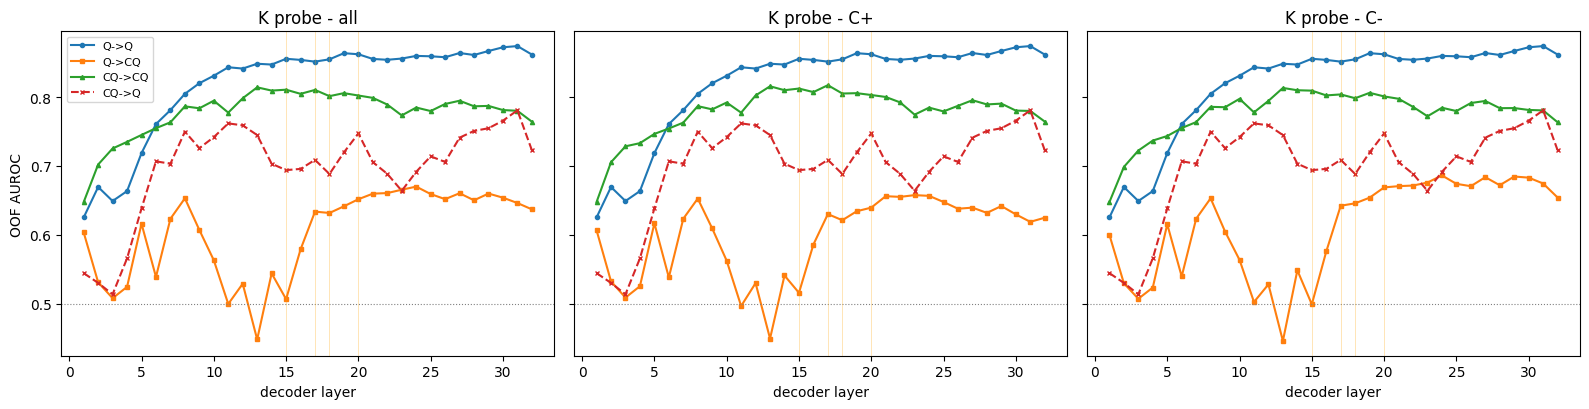

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for ax, sname in zip(axes, ["all", "C+", "C-"]):
    for (s_in, t_in), st in zip(PAIRS, ["-o", "-s", "-^", "--x"]):
        s = oof.query("train_input==@s_in and test_input==@t_in and subset==@sname") \
               .sort_values("layer")
        ax.plot(s["layer"], s["auroc"], st, ms=3, label=f"{s_in.upper()}->{t_in.upper()}")
    ax.axhline(0.5, color="gray", lw=0.8, ls=":")
    for Lr in CONFIG["LAYERS_REPORT"]:
        ax.axvline(Lr, color="orange", lw=0.5, alpha=0.4)
    ax.set_title(f"K probe - {sname}"); ax.set_xlabel("decoder layer")
axes[0].set_ylabel("OOF AUROC"); axes[0].legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG["OUT_DIR"], "layer_profile_K.png"), dpi=150)
plt.show()

## 13. Pipeline sanity check — `C± × Q`  ★ 게이트

같은 질문의 C+/C− 행은 Q 입력에서 **동일한 hidden**을 공유하므로 C probe는 구조적으로 0.5여야
한다. 여기서 벗어나면 질문-그룹 매핑이나 브로드캐스트에 버그가 있다는 뜻이고, 그러면 11절
결과도 믿을 수 없다. 대조로 `C±×CQ`는 P3 재현(기대 0.86~0.90)이어야 한다.

In [18]:
y_C = C_arr
sanity = []
for layer in CONFIG["LAYERS_REPORT"]:
    for inp in ["q", "cq"]:
        X = get_layer(INPUTS[inp], layer)
        dec, _, _ = cross_probe(X, X, y_C, FOLDS)
        sanity.append({"layer": layer, "input": inp, "auroc_C": safe_auc(y_C, dec)})
san = pd.DataFrame(sanity).pivot(index="layer", columns="input", values="auroc_C")
print(san.round(3).to_string())

q_max = float(np.nanmax(san["q"].values))
cq_mean = float(np.nanmean(san["cq"].values))
print(f"\nC×Q 최대 {q_max:.3f} | C×CQ 평균 {cq_mean:.3f}")
print("[OK] 구조적 null 정상" if abs(q_max - 0.5) < 0.08
      else "[FAIL] 파이프라인 버그 의심 — 11절 결과를 쓰지 말 것")
print("[OK] P3 재현" if 0.80 < cq_mean < 0.95
      else "[주의] P3(0.86~0.90)와 다름 — 프롬프트 템플릿 차이 가능성")
san.round(4).to_csv(os.path.join(CONFIG["OUT_DIR"], "sanity_C_probe.csv"))

input     cq    q
layer            
15     0.955  0.5
17     0.937  0.5
18     0.924  0.5
20     0.921  0.5

C×Q 최대 0.500 | C×CQ 평균 0.934
[OK] 구조적 null 정상
[OK] P3 재현


## 14. Shuffle null — qid 단위

K는 closed-book 라벨이라 질문 단위 속성이다. row 단위로 섞으면 같은 질문에 K+/K−가 섞여
실제 라벨 구조와 다른 null이 된다. → **질문 단위로 재배치 후 같은 질문의 두 행에 동일 K 부여.**

`N_SHUFFLE=20`은 개발용이다. empirical p 해상도가 `1/(n+1)`이므로 최종 보고용이면 200~1000.

In [19]:
def shuffle_null_qid(s_in, t_in, layer, n=None, seed=0):
    n = n or CONFIG["N_SHUFFLE"]
    Xs, Xt = get_layer(INPUTS[s_in], layer), get_layer(INPUTS[t_in], layer)
    rng = np.random.default_rng(seed)
    qs = pd.Series(y_K, index=qid_arr).groupby(level=0).first()
    uq_ids, uq_K = qs.index.values, qs.values
    out = []
    for _ in range(n):
        m = dict(zip(uq_ids, uq_K[rng.permutation(len(uq_K))]))
        y_sh = np.array([m[q] for q in qid_arr])
        assert pd.Series(y_sh, index=qid_arr).groupby(level=0).nunique().max() == 1
        dec, _, _ = cross_probe(Xs, Xt, y_sh, FOLDS)
        out.append(safe_auc(y_sh, dec))
    return np.array(out)

null_rows = []
Lnull = CONFIG["NULL_LAYER"]
for s_in, t_in in PAIRS:
    real = oof.query("train_input==@s_in and test_input==@t_in and "
                     "subset=='all' and layer==@Lnull")["auroc"]
    if real.empty:
        continue
    sc = shuffle_null_qid(s_in, t_in, Lnull); r = float(real.iloc[0])
    null_rows.append({"cond": f"{s_in.upper()}->{t_in.upper()}", "layer": Lnull, "real": r,
                      "null_mean": float(np.nanmean(sc)), "null_max": float(np.nanmax(sc)),
                      "emp_p": (int((sc >= r).sum()) + 1) / (len(sc) + 1), "n_shuffle": len(sc)})
    print(null_rows[-1], flush=True)

null_df = pd.DataFrame(null_rows)
null_df.round(4).to_csv(os.path.join(CONFIG["OUT_DIR"], "shuffle_null_qid.csv"), index=False)
null_df.round(3)

{'cond': 'Q->Q', 'layer': 17, 'real': 0.8513996291774071, 'null_mean': 0.4990865101976213, 'null_max': 0.5655270655270654, 'emp_p': 0.047619047619047616, 'n_shuffle': 20}
{'cond': 'Q->CQ', 'layer': 17, 'real': 0.6335554877221543, 'null_mean': 0.4885029451001673, 'null_max': 0.5444874055985167, 'emp_p': 0.047619047619047616, 'n_shuffle': 20}
{'cond': 'CQ->CQ', 'layer': 17, 'real': 0.8103010672455118, 'null_mean': 0.5021354802604803, 'null_max': 0.5631924659702439, 'emp_p': 0.047619047619047616, 'n_shuffle': 20}
{'cond': 'CQ->Q', 'layer': 17, 'real': 0.708712069823181, 'null_mean': 0.5039439469995026, 'null_max': 0.5488626599737711, 'emp_p': 0.047619047619047616, 'n_shuffle': 20}


,cond,layer,real,null_mean,null_max,emp_p,n_shuffle
0,Q->Q,17,0.851,0.499,0.566,0.048,20
1,Q->CQ,17,0.634,0.489,0.544,0.048,20
2,CQ->CQ,17,0.810,0.502,0.563,0.048,20
3,CQ->Q,17,0.709,0.504,0.549,0.048,20


## 15. Paired score 테이블

같은 질문에서 `score(Q)` / `score(CQ,C+)` / `score(CQ,C−)`가 얼마나 움직이는지.
paired bootstrap이나 상관 분석은 이 테이블에서 바로 돌리면 된다.

In [20]:
Lp = CONFIG["LAYERS_REPORT"][1]
sub = scores.query("layer==@Lp and train_input=='cq' and test_input=='cq'").copy()
sub["cell"] = np.where(sub["C"] == 1, "CQ_Cpos", "CQ_Cneg")
wide = sub.pivot_table(index=["qid", "K"], columns="cell", values="decision_score")
qser = (scores.query("layer==@Lp and train_input=='q' and test_input=='q'")
              .groupby("qid")["decision_score"].first().rename("Q"))
wide = wide.join(qser, on="qid")
wide.to_csv(os.path.join(CONFIG["OUT_DIR"], f"paired_scores_L{Lp}.csv"))

print(f"=== L{Lp} K별 평균 decision score ===")
print(wide.groupby(level="K").mean().round(3).to_string())
print("\n=== 조건 간 상관 (질문 단위) ===")
print(wide.corr().round(3).to_string())

=== L17 K별 평균 decision score ===
   CQ_Cneg  CQ_Cpos      Q
K                         
0   -1.505   -1.417 -3.015
1    3.878    4.102  4.846

=== 조건 간 상관 (질문 단위) ===
         CQ_Cneg  CQ_Cpos      Q
CQ_Cneg    1.000    0.939  0.683
CQ_Cpos    0.939    1.000  0.683
Q          0.683    0.683  1.000


## 16. Behavior probe (선택 — 기본 off)

`A_cb`(closed-book 답)가 있으므로 **P7 정의 그대로** 만들 수 있다.
```
accept = output follows contextual_answer (answer_surface)
retain = output follows parametric answer (A_cb)
```
구분 가능 조건은 `C±`가 아니라 `answer_surface != A_cb`다.
K−/C+에서도 `context == gold`지만 `A_cb != gold`이므로 두 후보가 분리된다.

`model_output` 컬럼이 없어 **생성을 돌려야 한다**(1,224 × 48토큰). K 실험이 끝난 뒤
`CONFIG["RUN_BEHAVIOR"] = True`로 바꾸고 이 셀부터 실행할 것.

In [21]:
if not CONFIG["RUN_BEHAVIOR"]:
    print("behavior 건너뜀 (CONFIG['RUN_BEHAVIOR'] = False)")
else:
    def match_answer(text, ans):
        if not isinstance(text, str) or not isinstance(ans, str) or not ans.strip():
            return False
        def norm(s):
            s = re.sub(r"\b(a|an|the)\b", " ", s.lower())
            return re.sub(r"\s+", " ", re.sub(r"[^\w\s]", " ", s)).strip()
        t, a = norm(text), norm(ans)
        return bool(a) and re.search(r"\b" + re.escape(a) + r"\b", t) is not None

    gen_path = os.path.join(CONFIG["OUT_DIR"], "p8s_with_gen.csv")
    if os.path.exists(gen_path):
        df["_gen"] = pd.read_csv(gen_path)["_gen"]
        print("생성 캐시 로드")
    else:
        @torch.no_grad()
        def generate_answers(id_lists, bs=2):
            outs = []
            for i in range(0, len(id_lists), bs):
                ch = id_lists[i:i + bs]; ml = max(len(x) for x in ch)
                ii = torch.full((len(ch), ml), tok.pad_token_id, dtype=torch.long)
                am = torch.zeros((len(ch), ml), dtype=torch.long)
                for j, ids in enumerate(ch):
                    ii[j, ml - len(ids):] = torch.tensor(ids); am[j, ml - len(ids):] = 1
                g = model.generate(input_ids=ii.to(model.device),
                                   attention_mask=am.to(model.device),
                                   max_new_tokens=CONFIG["MAX_NEW_TOKENS"],
                                   do_sample=False, use_cache=True,
                                   pad_token_id=tok.pad_token_id)
                outs += [tok.decode(g[j, ml:], skip_special_tokens=True) for j in range(g.size(0))]
                if i % 100 == 0:
                    print(f"  [gen] {i}/{len(id_lists)}", flush=True)
            return outs
        model.config.use_cache = True
        df["_gen"] = generate_answers([build_ids(r, "cq")[0] for _, r in df.iterrows()])
        model.config.use_cache = False
        df.to_csv(gen_path, index=False)

    sep = lo(df[COLMAP["ctx_answer"]]) != lo(df[COLMAP["param_answer"]])
    hc = df.apply(lambda r: match_answer(r["_gen"], r[COLMAP["ctx_answer"]]), axis=1)
    hr = df.apply(lambda r: match_answer(r["_gen"], r[COLMAP["param_answer"]]), axis=1)
    df["_beh"] = np.where(sep & hc & ~hr, 1, np.where(sep & hr & ~hc, 0, np.nan))

    print(f"구분 가능(surface != A_cb): {int(sep.sum())}/{len(df)}")
    print("\n셀별 유효 behavior 표본:")
    print(pd.crosstab(df["_K"].map({1: "K+", 0: "K-"}), df["_C"].map({1: "C+", 0: "C-"}),
                      values=df["_beh"].notna(), aggfunc="sum"))
    print("\n라벨 분포:")
    print(df["_beh"].map({1: "accept", 0: "retain"}).value_counts(dropna=False))

    m = df["_beh"].notna().values
    if m.sum() > 40:
        y_b = df.loc[m, "_beh"].values.astype(int)
        folds_b = list(GroupKFold(n_splits=CONFIG["N_SPLITS"]).split(
            np.zeros(int(m.sum())), y_b, groups=qid_arr[m]))
        brows = []
        for layer in CONFIG["LAYERS_REPORT"]:
            Xl = {i: get_layer(H[torch.tensor(m)], layer) for i, H in INPUTS.items()}
            for s_in, t_in in PAIRS:
                dec, _, _ = cross_probe(Xl[s_in], Xl[t_in], y_b, folds_b)
                brows.append({"layer": layer, "train_input": s_in, "test_input": t_in,
                              "auroc": safe_auc(y_b, dec), "n": int(m.sum())})
        bres = pd.DataFrame(brows)
        print("\n" + bres.pivot_table(index="layer", columns=["train_input", "test_input"],
                                      values="auroc").round(3).to_string())
        bres.round(4).to_csv(os.path.join(CONFIG["OUT_DIR"], "behavior_probe.csv"), index=False)
        print("\n주의: test_input='q'는 질문 내부 변동을 원리상 판별할 수 없다. "
              "질문 간 수용 경향 차이만 잡히므로 'context 없이 behavior 예측 가능'으로 읽지 말 것.")
    else:
        print("유효 표본 부족 — behavior probe 생략")

behavior 건너뜀 (CONFIG['RUN_BEHAVIOR'] = False)


## 17. 해석 기준

**in-domain 성능이 아니라 전이 패턴으로 읽는다.**

| 관찰 | 해석 |
|---|---|
| `CQ→CQ` 높음 | conflict를 읽은 same-pass hidden에서 K decode 가능 → **single-inference feasibility 지지 (RQ1)** |
| `Q→CQ`까지 높음 | Q에서 학습한 K boundary가 context 입력 후에도 transfer → **representation/decision boundary 보존 (RQ2)**, 더 강한 결과 |
| `CQ→CQ` 높지만 `Q→CQ` 낮음 | single-inference는 가능. 단 context가 K geometry를 **remap**한 것 → "동일 K direction 보존" 주장은 **금지** |
| `CQ→CQ`도 낮음 | context 이후 K를 안정적으로 읽기 어려움 → **K-gated single-pass 설계 자체를 재검토** |

**읽는 순서**
1. 13절 `C×Q ≈ 0.5` 확인. 깨지면 나머지 폐기.
2. 13절 `C×CQ ≈ 0.86~0.90` 확인 (P3 재현).
3. 11절 **`CQ→CQ (C−)`** — 가장 먼저 볼 숫자. `C+`에서만 높고 `C−`에서 떨어지면 정작 개입이
   필요한 조건에서 gate가 작동하지 않는다는 뜻이다.
4. `Q→CQ` vs `CQ→CQ` 격차로 RQ2 판정. **격차가 크면 "보존"이 아니라 "remap"이다.**
5. 14절 null, 11절 fold 표준편차로 거품 여부 확인.

**쓰면 안 되는 표현**
- "`K×CQ`와 `K×Q`의 AUROC가 비슷하므로 K representation이 보존된다" → 보존 주장은 오직
  `Q→CQ` 전이 결과로만 한다.
- 이 실험은 P7의 입력이 무엇이었는지를 **역추정하지 않는다.** p8s에서 두 입력 조건을 독립적으로
  직접 비교하는 것이다.